In [1]:
# ==========================================================
# AI Banking Assistant
# Module 8 - Customer Segmentation
# Step 3 - Load Dataset
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# ==========================================================
# Load Dataset
# ==========================================================

# If notebook is inside notebooks folder
dataset_path = "../datasets/customer_segmentation.csv"

# If notebook is in project root use:
# dataset_path = "datasets/customer_segmentation.csv"

df = pd.read_csv(dataset_path)

print("=" * 70)
print("CUSTOMER SEGMENTATION DATASET LOADED")
print("=" * 70)

# ==========================================================
# First 5 Rows
# ==========================================================

print("\nFirst 5 Rows")
print("-" * 70)
print(df.head())

# ==========================================================
# Last 5 Rows
# ==========================================================

print("\nLast 5 Rows")
print("-" * 70)
print(df.tail())

# ==========================================================
# Dataset Shape
# ==========================================================

print("\nDataset Shape")
print("-" * 70)
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

# ==========================================================
# Column Names
# ==========================================================

print("\nColumns")
print("-" * 70)

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

# ==========================================================
# Missing Values
# ==========================================================

print("\nMissing Values")
print("-" * 70)

missing = df.isnull().sum()

print(missing)

print("\nTotal Missing Values :", missing.sum())

# ==========================================================
# Data Types
# ==========================================================

print("\nData Types")
print("-" * 70)

print(df.dtypes)

# ==========================================================
# Dataset Information
# ==========================================================

print("\nDataset Information")
print("-" * 70)

df.info()

# ==========================================================
# Summary Statistics
# ==========================================================

print("\nSummary Statistics")
print("-" * 70)

print(df.describe(include="all"))

# ==========================================================
# Numeric Columns
# ==========================================================

print("\nNumeric Columns")
print("-" * 70)

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print(numeric_columns)

# ==========================================================
# Categorical Columns
# ==========================================================

print("\nCategorical Columns")
print("-" * 70)

categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print(categorical_columns)

# ==========================================================
# Unique Values (Categorical Columns)
# ==========================================================

if len(categorical_columns) > 0:

    print("\nUnique Values in Categorical Columns")
    print("-" * 70)

    for col in categorical_columns:

        print(f"\n{col}")

        print(df[col].nunique(), "Unique Values")

# ==========================================================
# Duplicate Rows
# ==========================================================

print("\nDuplicate Rows")
print("-" * 70)

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

print("\n" + "=" * 70)
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 70)

CUSTOMER SEGMENTATION DATASET LOADED

First 5 Rows
----------------------------------------------------------------------
       ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      19114.12            1824.843333                  3  ...           _   
1      19114.12                    NaN                  3  ...        Good   
2      19114.12                    NaN                  3  ...        Good   
3      19114.12                    NaN                  3  ...        Good   
4      

In [2]:
# ==========================================================
# AI Banking Assistant
# Module 8 - Customer Segmentation
# Step 4 - Data Cleaning
# ==========================================================


import pandas as pd
import numpy as np


print("="*70)
print("DATA CLEANING STARTED")
print("="*70)


# ==========================================================
# 1. Check Missing Values
# ==========================================================

print("\nMissing Values Before Handling")
print("-"*70)

print(df.isnull().sum())


# ==========================================================
# 2. Handle Missing Values
# ==========================================================

# Numeric columns
numeric_columns = df.select_dtypes(
    include=np.number
).columns


for col in numeric_columns:

    df[col] = df[col].fillna(
        df[col].median()
    )


# Categorical columns
categorical_columns = df.select_dtypes(
    exclude=np.number
).columns


for col in categorical_columns:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )


print("\nMissing Values After Handling")
print("-"*70)

print(df.isnull().sum())


# ==========================================================
# 3. Remove Duplicate Rows
# ==========================================================

print("\nDuplicate Rows Before Removal")
print("-"*70)

print(df.duplicated().sum())


df.drop_duplicates(
    inplace=True
)


print("\nDuplicate Rows After Removal")
print("-"*70)

print(df.duplicated().sum())


# ==========================================================
# 4. Correct Data Types
# ==========================================================


print("\nData Types Before Correction")
print("-"*70)

print(df.dtypes)


# Convert Customer_ID to string

if "Customer_ID" in df.columns:

    df["Customer_ID"] = (
        df["Customer_ID"]
        .astype(str)
    )


# Convert numeric columns

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# Fill any new NaN created

for col in numeric_columns:

    df[col] = df[col].fillna(
        df[col].median()
    )


print("\nData Types After Correction")
print("-"*70)

print(df.dtypes)



# ==========================================================
# 5. Outlier Detection
# Using IQR Method
# ==========================================================


print("\nOutlier Detection")
print("-"*70)


outlier_summary = {}


for col in numeric_columns:


    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)


    IQR = Q3 - Q1


    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR


    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]


    outlier_summary[col] = len(outliers)



outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=[
        "Feature",
        "Outlier_Count"
    ]
)


print(outlier_df)



# ==========================================================
# 6. Handle Outliers
# Using IQR Capping
# ==========================================================


for col in numeric_columns:


    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)


    IQR = Q3 - Q1


    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR


    df[col] = np.where(
        df[col] < lower_limit,
        lower_limit,
        df[col]
    )


    df[col] = np.where(
        df[col] > upper_limit,
        upper_limit,
        df[col]
    )


print("\nOutliers Handled Successfully")


# ==========================================================
# 7. Final Dataset Check
# ==========================================================

print("\nFinal Dataset Shape")
print("-"*70)

print(df.shape)


print("\nFinal Dataset Preview")
print("-"*70)

print(df.head())


print("\n" + "="*70)
print("STEP 4 COMPLETED SUCCESSFULLY")
print("="*70)

DATA CLEANING STARTED

Missing Values Before Handling
----------------------------------------------------------------------
ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour        

EXPLORATORY DATA ANALYSIS STARTED

Columns in Dataset:
['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


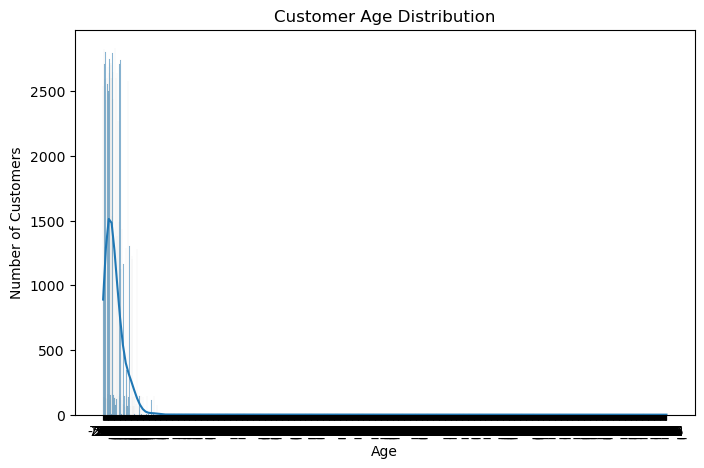

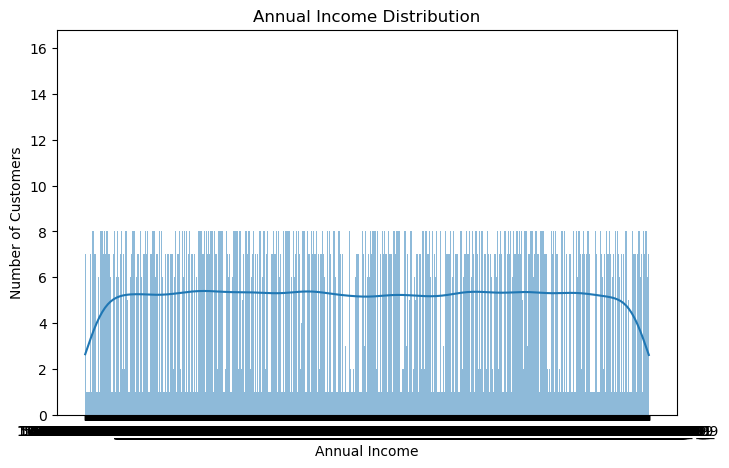

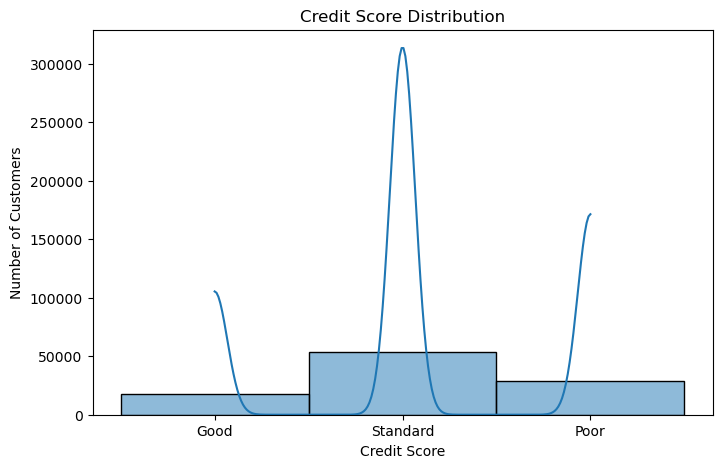

Loan Amount column not found.
Column 'Account_Balance' not found. Skipping...
Column 'Monthly_Income' not found. Skipping...


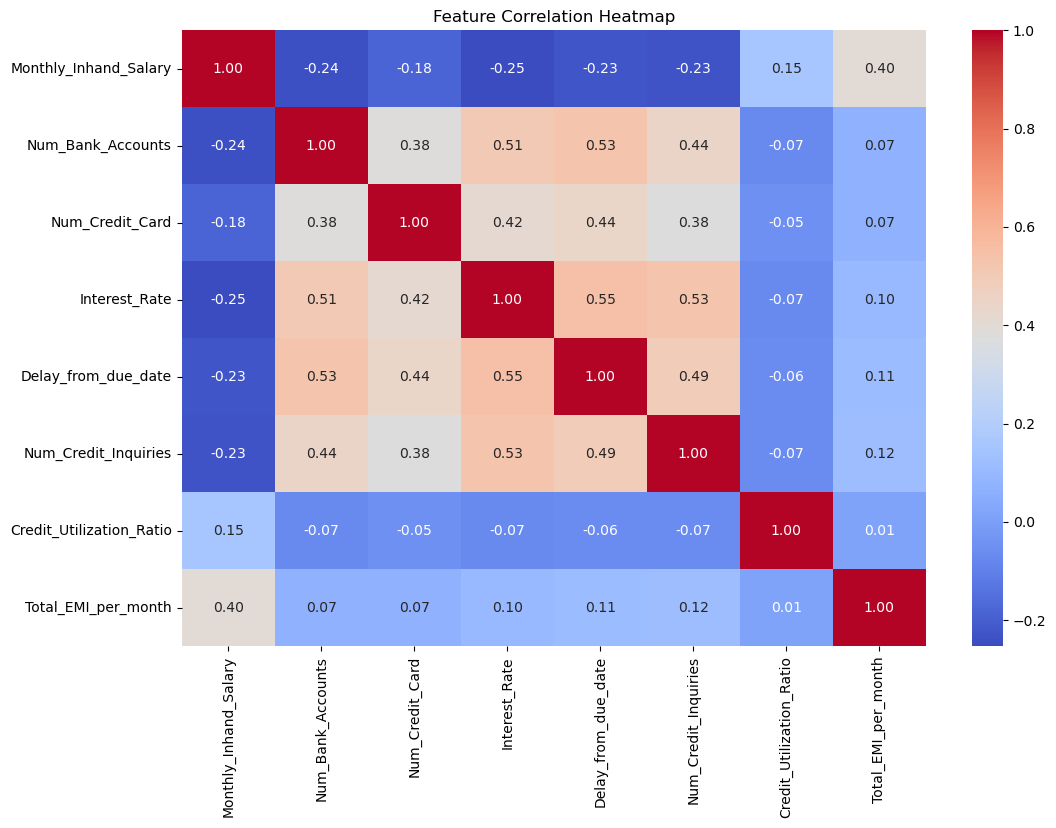


Correlation With Important Features
----------------------------------------------------------------------
Credit_Score column not available for correlation.

STEP 5 COMPLETED SUCCESSFULLY


In [3]:
# ==========================================================
# AI Banking Assistant
# Module 8 - Customer Segmentation
# Step 5 - Exploratory Data Analysis
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("EXPLORATORY DATA ANALYSIS STARTED")
print("="*70)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("\nColumns in Dataset:")
print(df.columns.tolist())


# ==========================================================
# Function to Plot Histogram
# ==========================================================

def plot_histogram(column_name, title, xlabel):
    if column_name in df.columns:
        plt.figure(figsize=(8,5))

        sns.histplot(
            df[column_name],
            bins=30,
            kde=True
        )

        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel("Number of Customers")

        plt.show()

    else:
        print(f"Column '{column_name}' not found. Skipping...")


# ==========================================================
# 1. Age Distribution
# ==========================================================

plot_histogram(
    "Age",
    "Customer Age Distribution",
    "Age"
)

# ==========================================================
# 2. Annual Income Distribution
# ==========================================================

plot_histogram(
    "Annual_Income",
    "Annual Income Distribution",
    "Annual Income"
)

# ==========================================================
# 3. Credit Score Distribution
# ==========================================================

plot_histogram(
    "Credit_Score",
    "Credit Score Distribution",
    "Credit Score"
)

# ==========================================================
# 4. Loan Amount Distribution
# ==========================================================

# Possible column names
loan_column = None

possible_loan_columns = [
    "Loan_Amount",
    "LoanAmount",
    "Loan Amount",
    "loan_amount",
    "LoanAmt"
]

for col in possible_loan_columns:
    if col in df.columns:
        loan_column = col
        break

if loan_column:
    plot_histogram(
        loan_column,
        "Loan Amount Distribution",
        "Loan Amount"
    )
else:
    print("Loan Amount column not found.")

# ==========================================================
# 5. Account Balance Distribution
# ==========================================================

plot_histogram(
    "Account_Balance",
    "Account Balance Distribution",
    "Account Balance"
)

# ==========================================================
# 6. Monthly Income Distribution
# ==========================================================

plot_histogram(
    "Monthly_Income",
    "Monthly Income Distribution",
    "Monthly Income"
)

# ==========================================================
# 7. Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# ==========================================================
# 8. Correlation Ranking
# ==========================================================

print("\nCorrelation With Important Features")
print("-"*70)

if "Credit_Score" in correlation.columns:
    print(
        correlation["Credit_Score"]
        .sort_values(ascending=False)
    )
else:
    print("Credit_Score column not available for correlation.")

print("\n" + "="*70)
print("STEP 5 COMPLETED SUCCESSFULLY")
print("="*70)

In [9]:
# ==========================================================
# Save Scaler + Feature Order
# ==========================================================

import os
import joblib

os.makedirs("ml/models", exist_ok=True)

# Save Scaler
joblib.dump(
    scaler,
    "ml/models/customer_scaler.pkl"
)

# Save Feature Order
joblib.dump(
    list(numeric_features),
    "ml/models/customer_feature_order.pkl"
)

print("\nScaler Saved")
print("ml/models/customer_scaler.pkl")

print("\nFeature Order Saved")
print("ml/models/customer_feature_order.pkl")


Scaler Saved
ml/models/customer_scaler.pkl

Feature Order Saved
ml/models/customer_feature_order.pkl


ELBOW METHOD STARTED
K = 1  |  WCSS = 800000.000000002
K = 2  |  WCSS = 574129.5806274947
K = 3  |  WCSS = 494895.4633131283
K = 4  |  WCSS = 460874.22297475697
K = 5  |  WCSS = 429507.66982595064
K = 6  |  WCSS = 408250.1950012972
K = 7  |  WCSS = 387173.3221488659
K = 8  |  WCSS = 370313.9162756075


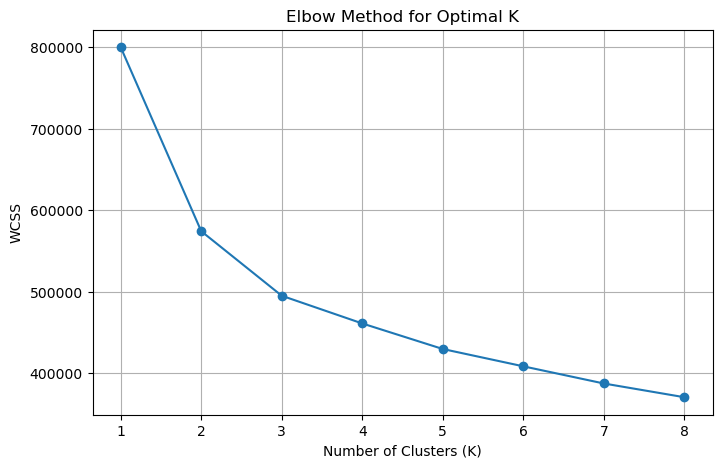


STEP 7 COMPLETED SUCCESSFULLY


In [5]:
# ==========================================================
# AI Banking Assistant
# Module 8 - Customer Segmentation
# Step 7 - Find Optimal Number of Clusters
# ==========================================================


import matplotlib.pyplot as plt

from sklearn.cluster import KMeans


print("="*70)
print("ELBOW METHOD STARTED")
print("="*70)



# ==========================================================
# Calculate WCSS for different K values
# ==========================================================


wcss = []


cluster_range = range(1, 9)



for k in cluster_range:

    kmeans = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )


    kmeans.fit(
        X_scaled_df
    )


    wcss.append(
        kmeans.inertia_
    )


    print(
        f"K = {k}  |  WCSS = {kmeans.inertia_}"
    )



# ==========================================================
# Plot Elbow Curve
# ==========================================================


plt.figure(
    figsize=(8,5)
)


plt.plot(

    list(cluster_range),

    wcss,

    marker="o"

)


plt.xlabel(
    "Number of Clusters (K)"
)


plt.ylabel(
    "WCSS"
)


plt.title(
    "Elbow Method for Optimal K"
)


plt.xticks(
    list(cluster_range)
)


plt.grid()


plt.show()



print("\n" + "="*70)
print("STEP 7 COMPLETED SUCCESSFULLY")
print("="*70)

SILHOUETTE SCORE ANALYSIS STARTED
k = 2  |  Silhouette Score = 0.2652
k = 3  |  Silhouette Score = 0.2198
k = 4  |  Silhouette Score = 0.1695
k = 5  |  Silhouette Score = 0.1551
k = 6  |  Silhouette Score = 0.1436
k = 7  |  Silhouette Score = 0.1413
k = 8  |  Silhouette Score = 0.1355


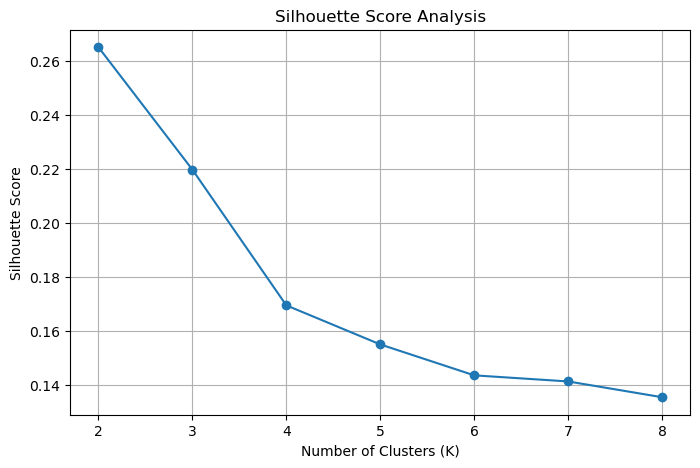


Best Number of Clusters
-----------------------
Optimal K : 2
Best Silhouette Score : 0.2652

STEP 8 COMPLETED SUCCESSFULLY


In [5]:
# ==========================================================
# AI Banking Assistant
# Module 8 - Customer Segmentation
# Step 8 - Validate Clusters
# ==========================================================


import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


print("="*70)
print("SILHOUETTE SCORE ANALYSIS STARTED")
print("="*70)



# ==========================================================
# Calculate Silhouette Score for Different K Values
# ==========================================================


silhouette_scores = []


k_values = range(2,9)



for k in k_values:


    kmeans = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )


    cluster_labels = kmeans.fit_predict(
        X_scaled_df
    )


    score = silhouette_score(

        X_scaled_df,

        cluster_labels

    )


    silhouette_scores.append(score)


    print(
        f"k = {k}  |  Silhouette Score = {round(score,4)}"
    )



# ==========================================================
# Plot Silhouette Scores
# ==========================================================


plt.figure(
    figsize=(8,5)
)


plt.plot(

    list(k_values),

    silhouette_scores,

    marker="o"

)


plt.xlabel(
    "Number of Clusters (K)"
)


plt.ylabel(
    "Silhouette Score"
)


plt.title(
    "Silhouette Score Analysis"
)


plt.xticks(
    list(k_values)
)


plt.grid()


plt.show()



# ==========================================================
# Find Best K
# ==========================================================


best_k = list(k_values)[
    silhouette_scores.index(
        max(silhouette_scores)
    )
]


best_score = max(
    silhouette_scores
)



print("\nBest Number of Clusters")

print("-----------------------")

print(
    "Optimal K :",
    best_k
)


print(
    "Best Silhouette Score :",
    round(best_score,4)
)



print("\n" + "="*70)
print("STEP 8 COMPLETED SUCCESSFULLY")
print("="*70)

In [6]:
# ==========================================================
# AI Banking Assistant
# Module 8 - Customer Segmentation
# Step 9 - Train K-Means Model
# ==========================================================


import os
import joblib
import pandas as pd

from sklearn.cluster import KMeans



print("="*70)
print("FINAL K-MEANS TRAINING STARTED")
print("="*70)



# ==========================================================
# Select Optimal K
# ==========================================================

# Replace this value with your best_k from Step 8

optimal_k = best_k


print(
    "Selected Number of Clusters:",
    optimal_k
)



# ==========================================================
# Train Final K-Means Model
# ==========================================================


kmeans_model = KMeans(

    n_clusters=optimal_k,

    random_state=42,

    n_init=10

)


cluster_labels = kmeans_model.fit_predict(

    X_scaled_df

)



print("\nK-Means Training Completed")



# ==========================================================
# Add Cluster Labels
# ==========================================================


customer_segments = X_scaled_df.copy()


customer_segments["Cluster"] = cluster_labels



print("\nCluster Distribution")
print("-"*70)


print(
    customer_segments["Cluster"]
    .value_counts()
)



# ==========================================================
# Preview Clustered Data
# ==========================================================


print("\nClustered Customer Data")

print(
    customer_segments.head()
)



# ==========================================================
# Save Model
# ==========================================================


os.makedirs(

    "../models",

    exist_ok=True

)


joblib.dump(

    kmeans_model,

    "../models/customer_segmentation_model.pkl"

)


print("\nK-Means Model Saved")

print(
    "../models/customer_segmentation_model.pkl"
)



# ==========================================================
# Save Clustered Dataset
# ==========================================================


os.makedirs(

    "../datasets/processed",

    exist_ok=True

)


customer_segments.to_csv(

    "../datasets/processed/customer_segments.csv",

    index=False

)



print("\nClustered Dataset Saved")

print(
    "../datasets/processed/customer_segments.csv"
)



print("\n"+"="*70)
print("STEP 9 COMPLETED SUCCESSFULLY")
print("="*70)

FINAL K-MEANS TRAINING STARTED
Selected Number of Clusters: 2

K-Means Training Completed

Cluster Distribution
----------------------------------------------------------------------
Cluster
1    64423
0    35577
Name: count, dtype: int64

Clustered Customer Data
   Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  \
0              -0.773146          -0.907532        -0.748691       -1.29644   
1              -0.313004          -0.907532        -0.748691       -1.29644   
2              -0.313004          -0.907532        -0.748691       -1.29644   
3              -0.313004          -0.907532        -0.748691       -1.29644   
4              -0.773146          -0.907532        -0.748691       -1.29644   

   Delay_from_due_date  Num_Credit_Inquiries  Credit_Utilization_Ratio  \
0            -1.240483             -0.484957                 -1.067570   
1            -1.517738             -0.484957                 -0.066486   
2            -1.240483             -0.4

In [7]:
# ==========================================================
# AI Banking Assistant
# Module 8 - Customer Segmentation
# Step 10 - Name Customer Segments
# ==========================================================


import pandas as pd


print("="*70)
print("CUSTOMER SEGMENT ANALYSIS")
print("="*70)



# ==========================================================
# Load Clustered Dataset
# ==========================================================


customer_segments = pd.read_csv(

    "../datasets/processed/customer_segments.csv"

)



print("\nCluster Data Loaded")

print(
    customer_segments.head()
)



# ==========================================================
# Cluster Profile Analysis
# ==========================================================


cluster_summary = customer_segments.groupby(
    "Cluster"
).mean()



print("\nCluster Average Profile")
print("-"*70)


print(
    cluster_summary
)



# ==========================================================
# Create Segment Names
# ==========================================================


segment_mapping = {

    0: "Premium Customers",

    1: "Regular Customers",

    2: "High Risk Customers",

    3: "Investment Customers"

}



# ==========================================================
# Apply Mapping
# ==========================================================


customer_segments["Customer_Segment"] = (

    customer_segments["Cluster"]
    .map(segment_mapping)

)



print("\nCustomer Segment Names Added")



print(
    customer_segments[
        [
            "Cluster",
            "Customer_Segment"
        ]
    ]
    .drop_duplicates()
)



# ==========================================================
# Segment Distribution
# ==========================================================


print("\nSegment Distribution")
print("-"*70)


print(

    customer_segments[
        "Customer_Segment"
    ]
    .value_counts()

)



# ==========================================================
# Save Final Segmentation Data
# ==========================================================


customer_segments.to_csv(

    "../datasets/processed/final_customer_segments.csv",

    index=False

)



print("\nFinal Segmented Dataset Saved")

print(

"../datasets/processed/final_customer_segments.csv"

)



print("\n"+"="*70)
print("STEP 10 COMPLETED SUCCESSFULLY")
print("="*70)

CUSTOMER SEGMENT ANALYSIS

Cluster Data Loaded
   Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  \
0              -0.773146          -0.907532        -0.748691       -1.29644   
1              -0.313004          -0.907532        -0.748691       -1.29644   
2              -0.313004          -0.907532        -0.748691       -1.29644   
3              -0.313004          -0.907532        -0.748691       -1.29644   
4              -0.773146          -0.907532        -0.748691       -1.29644   

   Delay_from_due_date  Num_Credit_Inquiries  Credit_Utilization_Ratio  \
0            -1.240483             -0.484957                 -1.067570   
1            -1.517738             -0.484957                 -0.066486   
2            -1.240483             -0.484957                 -0.718380   
3            -1.101856             -0.484957                 -0.177317   
4            -1.032542             -0.484957                 -1.463379   

   Total_EMI_per_month  Cluster  

In [8]:
# ==========================================================
# AI Banking Assistant
# Module 8 - Customer Segmentation
# Step 11 - Save Model
# ==========================================================


import os
import joblib


print("="*70)
print("SAVING CUSTOMER SEGMENTATION MODEL")
print("="*70)



# ==========================================================
# Create Model Folder
# ==========================================================


os.makedirs(

    "../models",

    exist_ok=True

)



# ==========================================================
# Save K-Means Model
# ==========================================================


joblib.dump(

    kmeans_model,

    "../models/customer_segmentation_model.pkl"

)


print("\nK-Means Model Saved")

print(
    "../models/customer_segmentation_model.pkl"
)



# ==========================================================
# Save Scaler
# ==========================================================


joblib.dump(

    scaler,

    "../models/customer_scaler.pkl"

)


print("\nScaler Saved")

print(
    "../models/customer_scaler.pkl"
)



print("\n"+"="*70)
print("STEP 11 COMPLETED SUCCESSFULLY")
print("="*70)

SAVING CUSTOMER SEGMENTATION MODEL

K-Means Model Saved
../models/customer_segmentation_model.pkl

Scaler Saved
../models/customer_scaler.pkl

STEP 11 COMPLETED SUCCESSFULLY
